# 10 -- Feature Selection (Redundancy + Relevance, leakage-safe)

**Pichle steps ka recap:** `08` ne ratios treat kiye, `09` ne features ka target ke saath rishta dekha.

**Ali Traders ki kahani:** Ali ke paas 13 munshi hain (13 ratio/growth features), har ek apni report banata hai. Feature selection ke 3 sawal hain:

1. **Kaun se munshi ek doosre ki nakal hain?** (Part 1 aur 2: redundancy)
2. **Kaun se munshi sach mein kaam ke hain?** (Part 3: relevance)
3. **Kis ko nikalna hai?** Sirf tab nikalo jab nikalne se nuksan na ho (Part 4 aur 5)

**Naya usool (1-standard-error rule):** Agar kisi feature ko nikalne se score utna hi badalta hai jitna fold-to-fold natural utar-chadhaav (noise) hota hai,
to us feature ke kaam ka koi saboot nahi. Aisi feature nikal do (simple model behtar). Lekin agar nikalne se score noise se zyada girta hai, to feature rakho, chahe woh kisi doosri jaisi lagti ho.

**Leakage-safe:** yeh notebook **sirf train companies** ke labels dekhti hai (`company_split.json`, `07` mein lock ki hui). Test companies ki koi row
kisi bhi faisle mein shamil nahi.

## Working directory fix (zaroori)

In [15]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [16]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
FS_DIR = REPORTS_DIR / "figures" / "feature_selection_charts"
FS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "08_ratios_treated.parquet"
OUTPUT_PATH = PROCESSED_DIR / "10_final_dataset.parquet"

RATIO_GROWTH = ["current_ratio", "cash_ratio", "debt_to_equity", "debt_to_assets", "gross_margin",
                "operating_margin", "net_profit_margin", "roa", "roe", "asset_turnover",
                "revenue_growth_qoq", "netincome_growth_qoq", "assets_growth_qoq"]
BINARY_CONTEXT = ["is_annual_filing", "has_inventory"]
TARGET = "target_next_quarter_health"

SEED = 42
N_FOLDS = 5
VIF_THRESHOLD = 5.0      # statistics ki standard convention
CORR_THRESHOLD = 0.6

sns.set_style("whitegrid")
print("Setup ready.")

Setup ready.


## Load 08 ka output

In [17]:
df = pd.read_parquet(INPUT_PATH)
print(f"Shape: {df.shape}")

needed = RATIO_GROWTH + BINARY_CONTEXT + [TARGET, "cik", "industry_sector"]
missing_cols = [c for c in needed if c not in df.columns]
assert not missing_cols, f"Ye columns dataset mein nahi hain: {missing_cols}"

SECTORS = sorted(df["industry_sector"].dropna().unique())
print(f"Industry sectors ({len(SECTORS)}): {SECTORS}")

Shape: (58241, 104)
Industry sectors (9): ['Agriculture', 'Construction', 'Finance_RealEstate', 'Manufacturing', 'Mining', 'Retail', 'Services', 'Transport_Utilities', 'Wholesale']


---
# PART 0 -- Selection set (leakage-safe)

**Kahani:** Test companies exam ka paper hain, jo `07` mein band kar diya gaya tha. Agar feature selection unhi companies ke labels dekh kar features chunta,
to final test result thoda "pehle se dekha hua" hota. Isliye selection sirf **train companies** ki labelled rows par hota hai, aur split `company_split.json`
se **padhi** jati hai (dobara nahi banai jati, taake `11`/`12` se mismatch na ho).

In [18]:
split = json.load(open(PROCESSED_DIR / "company_split.json"))
train_ciks, test_ciks = set(split["train_ciks"]), set(split["test_ciks"])
assert not (train_ciks & test_ciks), "MASLA: train aur test companies mein overlap!"

is_train_company = df["cik"].astype(str).isin(train_ciks)
sel = df[df[TARGET].notna() & is_train_company].copy()
assert not sel["cik"].astype(str).isin(test_ciks).any(), "MASLA: selection-set mein test company aa gayi!"

print(f"Selection companies (train): {sel['cik'].nunique()}   |   selection rows: {len(sel)}")
print(f"Test companies (10 ne kabhi nahi dekhi): {len(test_ciks)}")

Selection companies (train): 3922   |   selection rows: 27836
Test companies (10 ne kabhi nahi dekhi): 981


---
# PART 1 -- Redundancy: Correlation (Pearson aur Spearman dono)

**Kahani:** Do munshi ek jaisi report bana rahe hon to ek kaafi hai. Correlation batata hai kaun se features ek saath upar-neeche jate hain.

- **Pearson** = seedhi line ka rishta.
- **Spearman** = rank ka rishta (kaun pehle, kaun baad mein). Financial data mein kuch companies ke extreme values hote hain, isliye Spearman zyada mazboot hai.

Yeh sab **selection rows** par hai, poore dataset par nahi.

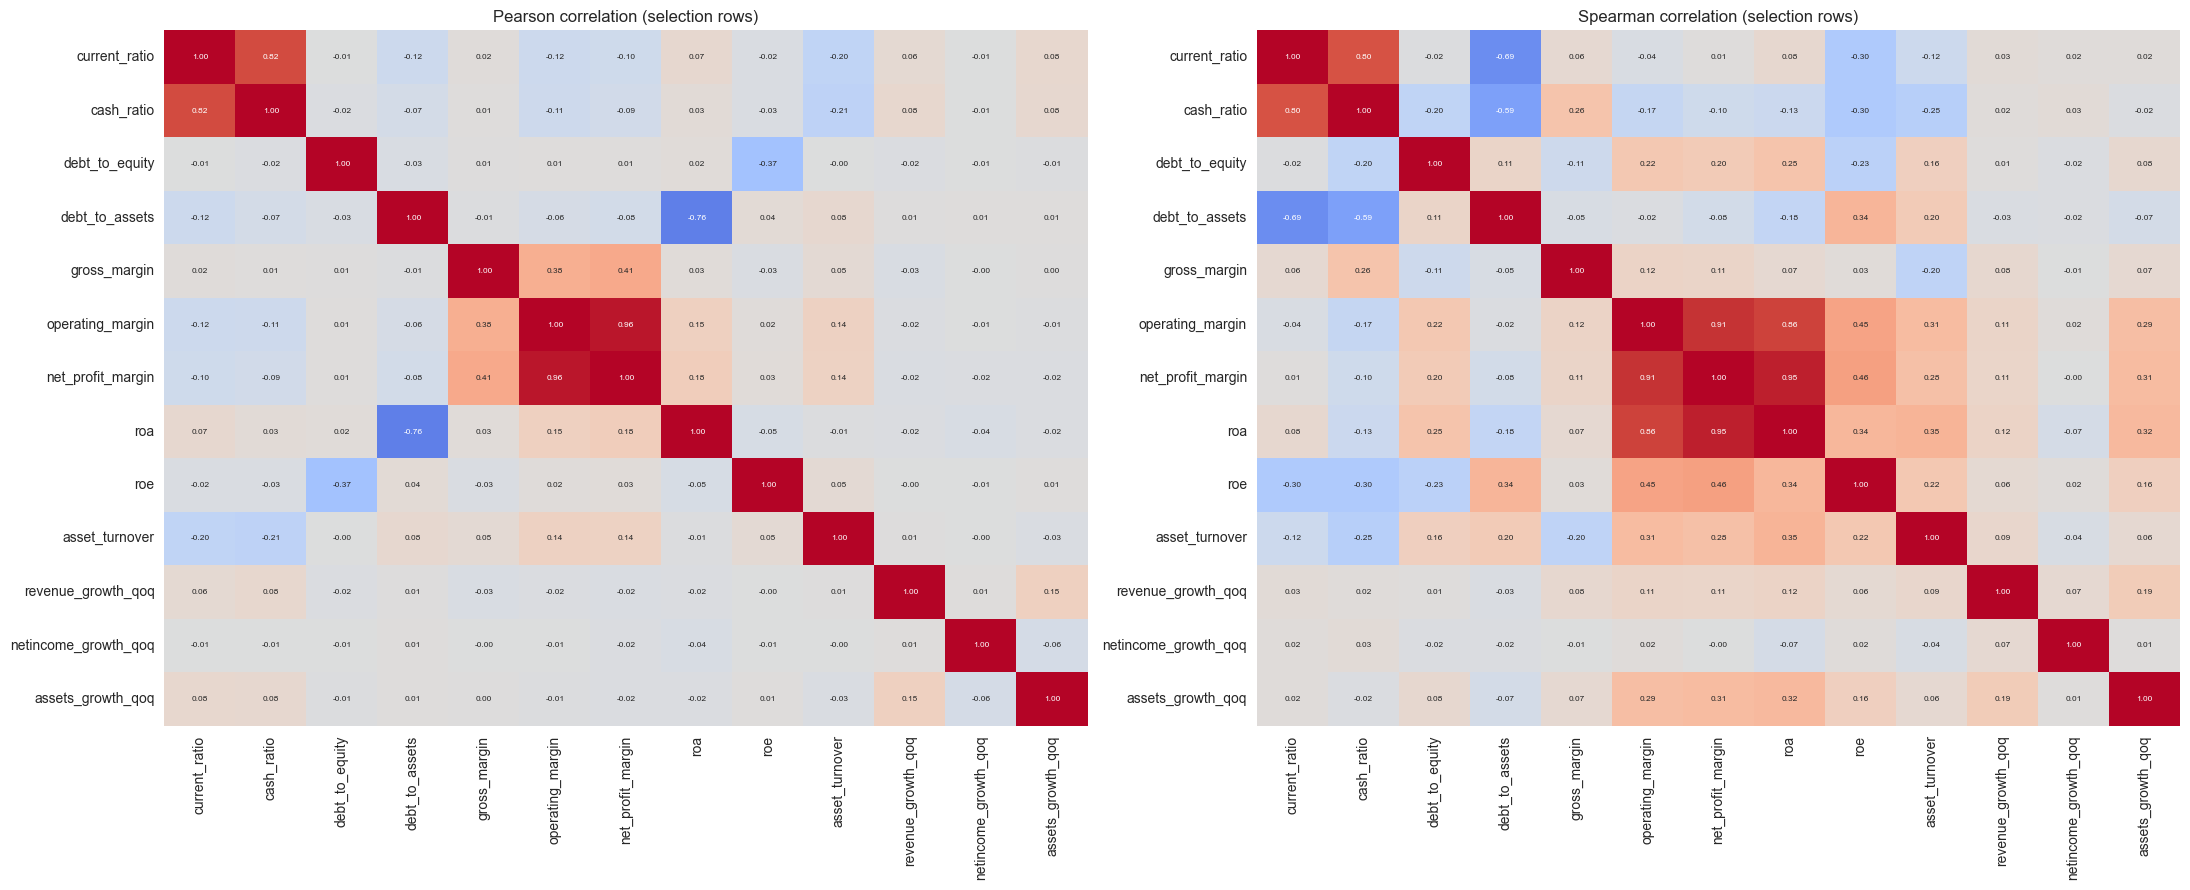

Pairs jinka |r| > 0.6 (Pearson ya Spearman mein): 6

                                pair  pearson  spearman                                                                                                                           wajah
          current_ratio ~ cash_ratio    0.823     0.802                     dono liquidity naapte hain; cash, current assets ka hissa hai aur denominator (LiabilitiesCurrent) same hai
      current_ratio ~ debt_to_assets   -0.118    -0.694                                                                            zyada liquid companies aksar kam leveraged hoti hain
                debt_to_assets ~ roa   -0.761    -0.181                                                                             dono ka denominator Assets hai (shared denominator)
operating_margin ~ net_profit_margin    0.961     0.906 dono profit-margin hain; denominator (Revenue) same aur numerator lagbhag same (net income = operating income - interest - tax)
              operating_mar

In [19]:
pearson = sel[RATIO_GROWTH].corr(method="pearson")
spear = sel[RATIO_GROWTH].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, mat, name in zip(axes, [pearson, spear], ["Pearson", "Spearman"]):
    sns.heatmap(mat, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
                annot_kws={"size": 6}, ax=ax, cbar=False)
    ax.set_title(f"{name} correlation (selection rows)")
plt.tight_layout()
plt.savefig(FS_DIR / "01_correlation_pearson_vs_spearman.png", dpi=110)
plt.show()

PAIR_REASONS = {
    frozenset({"current_ratio", "cash_ratio"}): "dono liquidity naapte hain; cash, current assets ka hissa hai aur denominator (LiabilitiesCurrent) same hai",
    frozenset({"operating_margin", "net_profit_margin"}): "dono profit-margin hain; denominator (Revenue) same aur numerator lagbhag same (net income = operating income - interest - tax)",
    frozenset({"net_profit_margin", "roa"}): "dono 'company profit mein hai ya nahi' ka signal hain; profitable companies dono mein upar rank hoti hain",
    frozenset({"operating_margin", "roa"}): "dono 'company profit mein hai ya nahi' ka signal hain; profitable companies dono mein upar rank hoti hain",
    frozenset({"debt_to_assets", "roa"}): "dono ka denominator Assets hai (shared denominator)",
    frozenset({"current_ratio", "debt_to_assets"}): "zyada liquid companies aksar kam leveraged hoti hain",
}

rows = []
for i, a in enumerate(RATIO_GROWTH):
    for b in RATIO_GROWTH[i + 1:]:
        p, s = pearson.loc[a, b], spear.loc[a, b]
        if abs(p) > CORR_THRESHOLD or abs(s) > CORR_THRESHOLD:
            rows.append({"pair": f"{a} ~ {b}", "pearson": round(p, 3), "spearman": round(s, 3),
                         "wajah": PAIR_REASONS.get(frozenset({a, b}), "manual review chahiye")})
pairs_df = pd.DataFrame(rows)
print(f"Pairs jinka |r| > {CORR_THRESHOLD} (Pearson ya Spearman mein): {len(pairs_df)}\n")
print(pairs_df.to_string(index=False) if len(pairs_df) else "Koi pair nahi mila.")

**Insight kaise padhein:** Jo pair sirf Spearman mein upar hai wahan rishta "seedhi line" ka nahi, "rank" ka hai. Jo sirf Pearson mein upar hai, woh chand extreme companies ki wajah se ho sakta hai.
**Correlation sirf ishara hai, faisla Part 4 mein CV se hoga**, kyunki kai baar ek jaisi lagne wali features mein bhi thoda alag signal hota hai.

## Part 1b -- Context features ka aapas mein overlap (Cramer's V)

**Kahani:** `06` mein humne dekha tha ke missingness industry se juri hai, yaani `has_inventory` aur `industry_sector` shayad ek doosre ki jhalak hon. Cramer's V categorical features ke liye
"kitna judey hue hain" ka number hai (0 = koi rishta nahi, 1 = bilkul ek jaisi).

In [20]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct)[0]
    return float(np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))))

ctx = sel[["has_inventory", "is_annual_filing", "industry_sector"]]
overlap_rows = []
for a, b in [("has_inventory", "industry_sector"), ("is_annual_filing", "industry_sector"), ("has_inventory", "is_annual_filing")]:
    overlap_rows.append({"pair": f"{a} ~ {b}", "cramers_v": round(cramers_v(ctx[a], ctx[b]), 3)})
context_overlap = pd.DataFrame(overlap_rows)
print(context_overlap.to_string(index=False))

                              pair  cramers_v
   has_inventory ~ industry_sector      0.472
is_annual_filing ~ industry_sector      0.013
  has_inventory ~ is_annual_filing      0.006


---
# PART 2 -- VIF (Variance Inflation Factor)

**Kahani:** VIF har munshi ke liye ek sawal poochta hai: *"kya baaki munshi milkar iska kaam kar sakte hain?"* VIF = 1 matlab kahani bilkul alag. VIF = 5 (threshold) matlab uska ~80% kaam baaki features se ho jata hai.

Jab bohat si rows median se bhar di jayen, to bhari hui values ek jaisi ho kar features ke beech ka rishta **bigaad deti hain**. Isliye **teen tareeqe saath dikhate hain:**
1. **Pairwise correlation matrix se VIF (primary):** har pair ki correlation un rows se jahan dono maujood hon. Ek bhi row zaya nahi hoti aur imputation ki zaroorat nahi.
2. **Complete-case VIF:** sirf woh rows jahan saare features maujood hon (row-set chhota aur khaas hota hai, isliye natije hilte hain).
3. **Median-imputed VIF:** sirf mawazna ke liye.

Primary method: pairwise-correlation
Complete-case rows: 7295 of 27836 (26.2%)
                      VIF_primary  VIF_complete_case  VIF_median_imputed
net_profit_margin           13.79              13.03               10.50
operating_margin            13.34              12.65               10.29
current_ratio                3.16               3.28                2.29
cash_ratio                   3.14               3.24                2.25
roa                          2.47               1.39                2.09
debt_to_assets               2.43               1.41                2.09
gross_margin                 1.23               1.36                1.08
roe                          1.17               1.15                1.15
debt_to_equity               1.17               1.14                1.15
asset_turnover               1.08               1.15                1.05
assets_growth_qoq            1.03               1.04                1.01
revenue_growth_qoq           1.03            

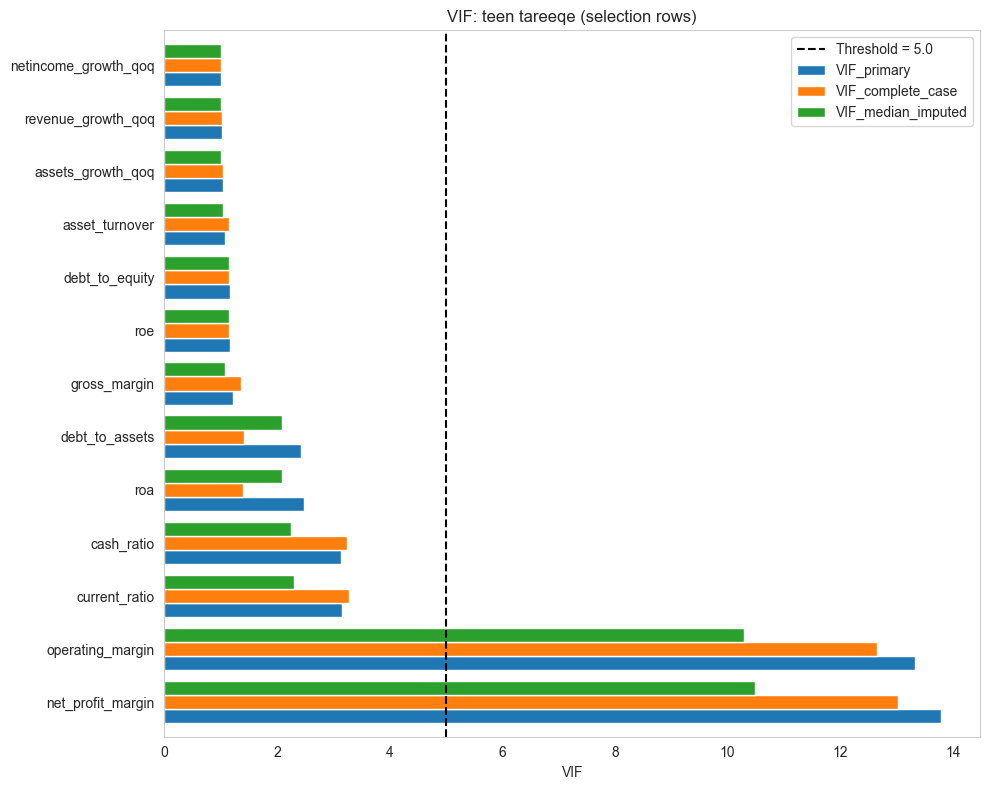


Primary VIF > 5.0 wali features: ['operating_margin', 'net_profit_margin']


In [21]:
def vif_from_corr(data, feats):
    R = data[feats].corr().values
    min_eig = float(np.linalg.eigvalsh(R).min())
    return pd.Series(np.diag(np.linalg.inv(R)), index=feats), min_eig

def vif_complete_case(data, feats):
    X = sm.add_constant(data[feats].dropna(), has_constant="add")
    vals = {n: variance_inflation_factor(X.values, i) for i, n in enumerate(X.columns) if n != "const"}
    return pd.Series(vals), len(X)

def vif_imputed(data, feats):
    X = sm.add_constant(data[feats].fillna(data[feats].median()), has_constant="add")
    return pd.Series({n: variance_inflation_factor(X.values, i) for i, n in enumerate(X.columns) if n != "const"})

def vif_primary(data, feats):
    """Pairwise-correlation VIF; agar matrix valid na ho to complete-case par fallback."""
    try:
        v, min_eig = vif_from_corr(data, feats)
        if min_eig > 1e-8:
            return v, "pairwise-correlation"
    except np.linalg.LinAlgError:
        pass
    return vif_complete_case(data, feats)[0], "complete-case (fallback)"

v_primary, method_used = vif_primary(sel, RATIO_GROWTH)
v_cc, n_cc = vif_complete_case(sel, RATIO_GROWTH)
v_imp = vif_imputed(sel, RATIO_GROWTH)

vif_table = pd.DataFrame({"VIF_primary": v_primary, "VIF_complete_case": v_cc, "VIF_median_imputed": v_imp})
vif_table = vif_table.sort_values("VIF_primary", ascending=False)
print(f"Primary method: {method_used}")
print(f"Complete-case rows: {n_cc} of {len(sel)} ({n_cc / len(sel):.1%})")
print(vif_table.round(2).to_string())

ax = vif_table.plot(kind="barh", figsize=(10, 8), width=0.8)
ax.axvline(VIF_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {VIF_THRESHOLD}")
ax.set_xlabel("VIF")
ax.set_title("VIF: teen tareeqe (selection rows)")
ax.legend()
plt.tight_layout()
plt.grid(False)
plt.savefig(FS_DIR / "02_vif_three_views.png", dpi=110)
plt.show()

flagged_initial = list(v_primary[v_primary > VIF_THRESHOLD].index)
print(f"\nPrimary VIF > {VIF_THRESHOLD} wali features: {flagged_initial if flagged_initial else 'koi nahi'}")

**Insight kaise padhein:** Agar koi feature primary VIF mein threshold se upar hai to woh kisi "twin" ke saath ek hi kahani suna rahi hai. **Lekin VIF sirf ishara hai, hukm nahi.** Teeno columns ke natije alag ho sakte hain:
complete-case sirf ek chhote, khaas row-set par hai (upar dekhein kitna %), aur median-imputed imputation se mutasir hai. Faisla sirf ek VIF number par nahi hona chahiye, woh Part 4 mein performance dekh kar hoga.

---
# PART 3 -- Relevance: kaun si feature model ke kaam ki hai?

**Kahani:** Har munshi ko ek-ek kar ke **chhutti par bhejte hain** (uski values shuffle karte hain) aur dekhte hain report kitni kharab hui. Jis ke jaane se kuch nahi bigda, uska kaam sawaliya hai. Isay **permutation importance** kehte hain.

- Score: **ROC-AUC** (0.5 = andaza, 1.0 = perfect; class imbalance se mutasir nahi hota).
- **Units:** har ratio/growth feature aur `is_annual_filing`, `has_inventory` ek ek unit hain. `industry_sector` ke **dummy columns ek saath ek unit** hain (kyunki woh ek hi cheez ke hisse hain).
- Sab kuch **5-fold GroupKFold (`cik` se grouped)** mein, sirf selection rows par. Yaani kisi company ke rows train aur validation dono mein nahi jate.
- **Ehtiyat:** jo features ek doosri ki twin hon unki importance aapas mein bat jati hai (shuffle karo to twin kaam chala leti hai), isliye twins ka faisla Part 4 mein "nikal kar dekho" se hoga.

In [22]:
SECTOR_COLS = [f"sector_{s}" for s in SECTORS]
UNITS = {c: [c] for c in RATIO_GROWTH + BINARY_CONTEXT}
UNITS["industry_sector"] = SECTOR_COLS

def make_X(data):
    cat = pd.Categorical(data["industry_sector"], categories=SECTORS)   # hamesha saare sector columns
    dummies = pd.get_dummies(cat, prefix="sector").astype(int)
    dummies.index = data.index
    return pd.concat([data[RATIO_GROWTH + BINARY_CONTEXT].astype(float), dummies], axis=1)

X_all = make_X(sel)
y_all = sel[TARGET].values
groups_all = sel["cik"].values
ALL_COLS = list(X_all.columns)
FOLDS = list(GroupKFold(n_splits=N_FOLDS).split(X_all, y_all, groups_all))

def fit_score(Xtr, ytr, Xva, yva):
    m = HistGradientBoostingClassifier(random_state=SEED).fit(Xtr, ytr)
    p = m.predict_proba(Xva)[:, list(m.classes_).index("Healthy")]
    return roc_auc_score(yva == "Healthy", p), m

def cols_without(units_dropped):
    drop = {c for u in units_dropped for c in UNITS[u]}
    return [c for c in ALL_COLS if c not in drop]

_cv_cache = {}
def cv_units(dropped):
    """Har fold ka AUC, jab 'dropped' units model se hata diye jayein."""
    key = tuple(sorted(dropped))
    if key not in _cv_cache:
        cols = cols_without(dropped)
        _cv_cache[key] = np.array([fit_score(X_all.iloc[tr][cols], y_all[tr], X_all.iloc[va][cols], y_all[va])[0]
                                   for tr, va in FOLDS])
    return _cv_cache[key]

t0 = time.time()
base = cv_units([])
print(f"Baseline (saari features) selection-CV AUC = {base.mean():.4f} +/- {base.std():.4f}   [{time.time() - t0:.0f}s]")

Baseline (saari features) selection-CV AUC = 0.9424 +/- 0.0036   [8s]


Permutation importance done [28s]

                      auc_drop_mean  auc_drop_std  low_relevance
current_ratio                0.1900        0.0054          False
roa                          0.1534        0.0117          False
operating_margin             0.0236        0.0031          False
netincome_growth_qoq         0.0124        0.0014          False
industry_sector              0.0031        0.0011          False
net_profit_margin            0.0016        0.0005          False
roe                          0.0015        0.0005          False
debt_to_assets               0.0011        0.0005          False
revenue_growth_qoq           0.0008        0.0001          False
debt_to_equity               0.0008        0.0004          False
assets_growth_qoq            0.0006        0.0004          False
asset_turnover               0.0005        0.0001          False
is_annual_filing             0.0005        0.0002          False
cash_ratio                   0.0003        0.0002      

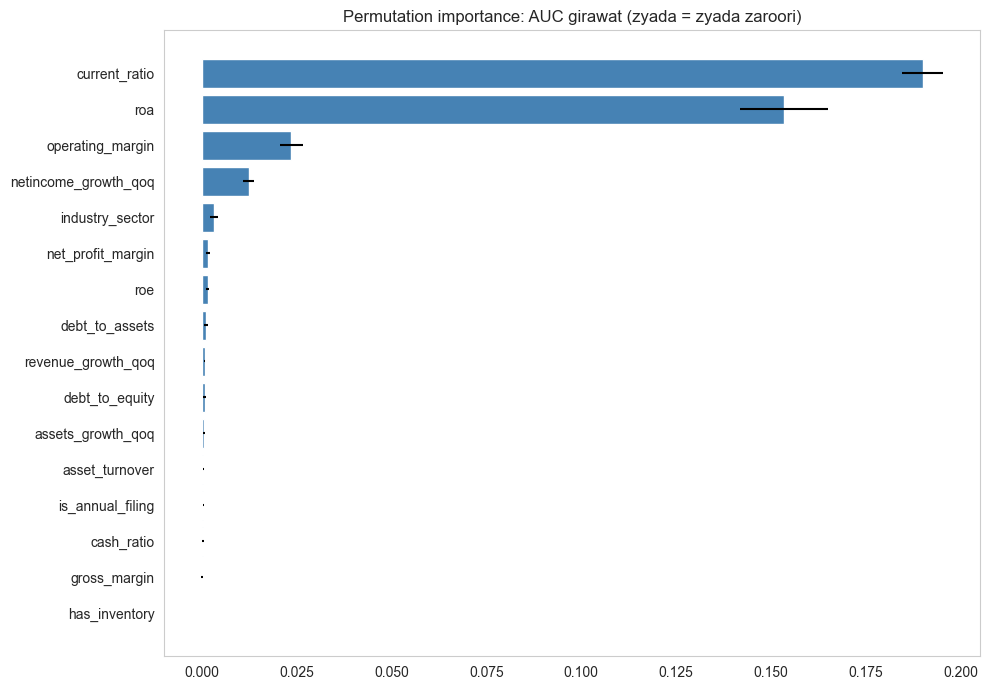


Top-3 units: ['current_ratio', 'roa', 'operating_margin']
Kam-relevance (importance <= fold-noise): ['gross_margin']


In [23]:
def permutation_importance_units(n_repeats=5):
    rng = np.random.default_rng(SEED)
    out = {u: [] for u in UNITS}
    for tr, va in FOLDS:
        s0, model = fit_score(X_all.iloc[tr], y_all[tr], X_all.iloc[va], y_all[va])
        Xv = X_all.iloc[va]
        for u, cols in UNITS.items():
            drops = []
            for _ in range(n_repeats):
                Xp = Xv.copy()
                Xp[cols] = Xv[cols].values[rng.permutation(len(Xv))]   # unit ke saare columns ek saath shuffle
                p = model.predict_proba(Xp)[:, list(model.classes_).index("Healthy")]
                drops.append(s0 - roc_auc_score(y_all[va] == "Healthy", p))
            out[u].append(np.mean(drops))
    return pd.DataFrame(out).T   # units x folds

t0 = time.time()
PI = permutation_importance_units()
pi_summary = pd.DataFrame({"auc_drop_mean": PI.mean(axis=1), "auc_drop_std": PI.std(axis=1)})
pi_summary["low_relevance"] = pi_summary["auc_drop_mean"] <= pi_summary["auc_drop_std"]
print(f"Permutation importance done [{time.time() - t0:.0f}s]\n")
print(pi_summary.sort_values("auc_drop_mean", ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
s = pi_summary.sort_values("auc_drop_mean")
ax.barh(s.index, s["auc_drop_mean"], xerr=s["auc_drop_std"], color="steelblue")
ax.set_title("Permutation importance: AUC girawat (zyada = zyada zaroori)")
plt.tight_layout()
plt.savefig(FS_DIR / "03_permutation_importance.png", dpi=110)
plt.grid(False)
plt.show()

low_rel = pi_summary.index[pi_summary["low_relevance"]].tolist()
print(f"\nTop-3 units: {pi_summary['auc_drop_mean'].nlargest(3).index.tolist()}")
print(f"Kam-relevance (importance <= fold-noise): {low_rel if low_rel else 'koi nahi'}")

---
# PART 4 -- Redundancy resolve karna (VIF flag + performance ka imtihan)

**Kahani:** Do twin munshi hon to ek ko nikalna chahiye, **lekin sirf tab jab uske jaane se report kharab na ho.** Agar dono ki mojoodgi se report behtar hai, to dono rakhte hain.

**Usool:**
1. Jo features primary VIF mein threshold se upar hon unhein "flagged" kaho.
2. Har flagged feature ko ek-ek kar ke nikal kar CV score dekho. **Nuksan (harm)** = AUC kitne % gira.
3. Jis ko nikalne se **sabse kam nuksan** ho use chuno. Agar do twins ke nuksan mein farq noise ke andar ho (tie), to woh nikalo jis ka **coverage kam** ho (zyada missing).
4. **Agar chune hue ko nikalne se nuksan noise (1 standard error) se zyada ho, to kuch mat nikalo:** "redundant lekin informative", tree model isay tolerate kar leta hai.
5. Nikalne ke baad VIF dobara dekho aur dohrao.

In [24]:
COVERAGE = sel[RATIO_GROWTH].notna().mean()

def se(a):
    return float(a.std(ddof=1) / np.sqrt(len(a)))

def harm(ref_dropped, extra):
    """Nuksan (relative) har fold mein: positive = nikalne se model kharab hua."""
    ref = cv_units(ref_dropped)
    red = cv_units(list(ref_dropped) + list(extra))
    return (ref - red) / ref

def within_noise(a):
    return a.mean() <= se(a)

dropped_redundancy, redundant_but_kept, log_rows = [], [], []
t0 = time.time()
while True:
    feats = [f for f in RATIO_GROWTH if f not in dropped_redundancy]
    v, _ = vif_primary(sel, feats)
    flagged = list(v[v > VIF_THRESHOLD].index)
    if not flagged:
        break
    stats = {f: harm(dropped_redundancy, [f]) for f in flagged}
    order = sorted(flagged, key=lambda f: stats[f].mean())
    best, note = order[0], "sabse kam nuksan"
    if len(order) > 1:
        d = stats[order[0]] - stats[order[1]]
        if abs(d.mean()) < se(d):
            best, note = min(order[:2], key=lambda f: COVERAGE[f]), "tie -> kam coverage wali"
    ok = within_noise(stats[best])
    for f in flagged:
        log_rows.append({"round": len(dropped_redundancy) + 1, "feature": f, "VIF": round(float(v[f]), 2),
                         "harm_%": round(100 * stats[f].mean(), 3), "SE_%": round(100 * se(stats[f]), 3)})
    if ok:
        dropped_redundancy.append(best)
        print(f"Round {len(dropped_redundancy)}: '{best}' nikala gaya ({note}); nuksan noise ke andar.")
    else:
        redundant_but_kept.append({"features": flagged, "VIF": {f: round(float(v[f]), 2) for f in flagged},
                                   "least_harm_candidate": best,
                                   "harm_%": round(100 * stats[best].mean(), 3), "SE_%": round(100 * se(stats[best]), 3)})
        print(f"Chune hue candidate '{best}' ({note}) ko nikalne se nuksan noise se zyada hai -> {flagged} REDUNDANT LEKIN INFORMATIVE, rakhe gaye.")
        break

redundancy_log = pd.DataFrame(log_rows)
print(f"\n[{time.time() - t0:.0f}s]")
print(redundancy_log.to_string(index=False) if len(redundancy_log) else "Koi feature VIF threshold se upar nahi tha.")
print(f"\nRedundancy ki wajah se nikali gayi units: {dropped_redundancy if dropped_redundancy else 'koi nahi'}")

Round 1: 'net_profit_margin' nikala gaya (sabse kam nuksan); nuksan noise ke andar.

[30s]
 round           feature   VIF  harm_%  SE_%
     1  operating_margin 13.34   0.179 0.047
     1 net_profit_margin 13.79  -0.017 0.034

Redundancy ki wajah se nikali gayi units: ['net_profit_margin']


**Insight kaise padhein:** `harm_%` wo % hai jitna model kharab hota agar us feature ko nikala jaye, `SE_%` fold-to-fold natural utar-chadhaav (noise). **Agar harm noise se bada hai, to us feature mein sach-much alag information hai**
chahe VIF ne use "twin" kaha ho. Yahi wajah hai ke sirf VIF ya sirf correlation par bharosa karna khatarnak hai.

---
# PART 5 -- Relevance ke hisaab se nikalna (1-standard-error rule)

**Usool:**
1. Part 3 mein jo units **kam-relevance** nikleen woh candidates hain (jo redundancy mein pehle nahi nikal chuke).
2. Har candidate ko nikal kar dekho: kya nuksan noise ke andar hai? Agar haan, to tentatively nikalne layak hai.
3. **Joint check:** sab tentative units ek saath nikaal kar dekho. Ek ek ka nuksan chhota ho sakta hai lekin mil kar bara ho sakta hai. Agar joint nuksan noise se bara ho, to sab se zyada nuksan wali unit wapas rakh do aur dobara check karo.

**Ehtiyat:** "nuksan noise ke andar" ka matlab hai "foyde ka saboot nahi", "bekaar hone ka saboot" nahi. Tree models mein extra feature ka nuksan bohat kam hota hai, isliye yeh usool parsimony (sada model) ke liye hai.

In [25]:
candidates = [u for u in low_rel if u not in dropped_redundancy]
print(f"Relevance candidates: {candidates if candidates else 'koi nahi'}\n")

rel_rows, tentative, indiv_harm = [], [], {}
for u in candidates:
    h = harm(dropped_redundancy, [u])
    ok = within_noise(h)
    indiv_harm[u] = float(h.mean())
    rel_rows.append({"unit": u, "harm_%": round(100 * h.mean(), 3), "SE_%": round(100 * se(h), 3),
                     "nateeja": "noise ke andar" if ok else "NUKSAN (rakho)"})
    if ok:
        tentative.append(u)
relevance_log = pd.DataFrame(rel_rows)
print(relevance_log.to_string(index=False) if len(relevance_log) else "-")

accepted = list(tentative)
while accepted:
    h = harm(dropped_redundancy, accepted)
    joint_ok = within_noise(h)
    print(f"\nJoint check {accepted}: harm={100 * h.mean():.3f}% (SE {100 * se(h):.3f}%) -> {'theek' if joint_ok else 'NUKSAN'}")
    if joint_ok:
        break
    worst = max(accepted, key=lambda u: indiv_harm[u])
    accepted.remove(worst)
    print(f"  '{worst}' wapas rakhi gayi.")

dropped_relevance = accepted
print(f"\nRelevance ki wajah se nikali gayi units: {dropped_relevance if dropped_relevance else 'koi nahi'}")

Relevance candidates: ['gross_margin']

        unit  harm_%  SE_%        nateeja
gross_margin  -0.017 0.014 noise ke andar

Joint check ['gross_margin']: harm=-0.017% (SE 0.014%) -> theek

Relevance ki wajah se nikali gayi units: ['gross_margin']


---
# PART 6 -- Final feature set + confirmation

Selected ratio/growth features (11): ['current_ratio', 'cash_ratio', 'debt_to_equity', 'debt_to_assets', 'operating_margin', 'roa', 'roe', 'asset_turnover', 'revenue_growth_qoq', 'netincome_growth_qoq', 'assets_growth_qoq']
Selected binary context features: ['is_annual_filing', 'has_inventory']
industry_sector istemal hoga: True
Nikali gayi units: ['net_profit_margin', 'gross_margin']

Selection-CV AUC (baseline -> final): 0.9424 -> 0.9427

Final VIF (pairwise-correlation) -- sabse bara: current_ratio = 3.15


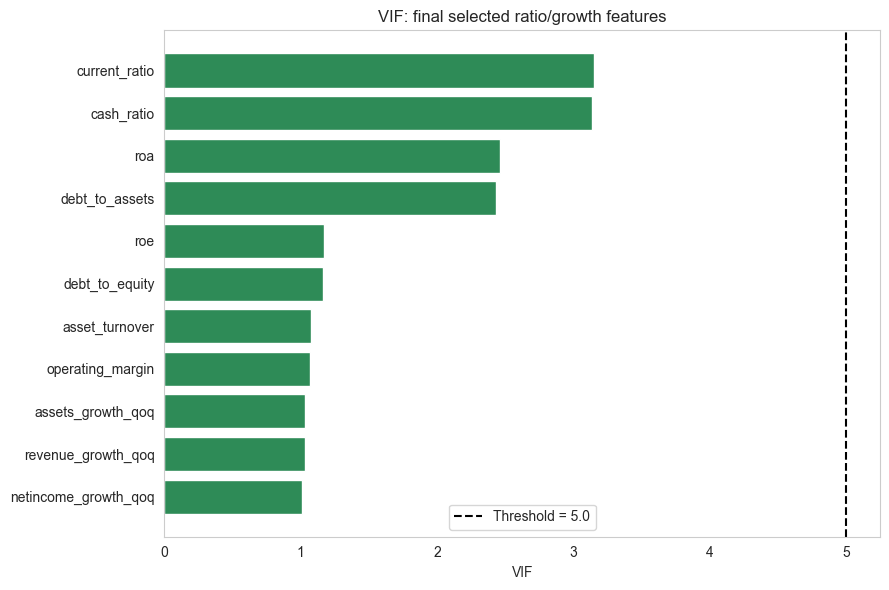

In [26]:
dropped_all = dropped_redundancy + dropped_relevance
selected_ratio_growth = [f for f in RATIO_GROWTH if f not in dropped_all]
selected_binary = [b for b in BINARY_CONTEXT if b not in dropped_all]
use_industry_sector = "industry_sector" not in dropped_all

v_final, method_final = vif_primary(sel, selected_ratio_growth)
still_flagged = list(v_final[v_final > VIF_THRESHOLD].index)

final_cv = cv_units(dropped_all)
print(f"Selected ratio/growth features ({len(selected_ratio_growth)}): {selected_ratio_growth}")
print(f"Selected binary context features: {selected_binary}")
print(f"industry_sector istemal hoga: {use_industry_sector}")
print(f"Nikali gayi units: {dropped_all if dropped_all else 'koi nahi'}")
print(f"\nSelection-CV AUC (baseline -> final): {base.mean():.4f} -> {final_cv.mean():.4f}")
print(f"\nFinal VIF ({method_final}) -- sabse bara: {v_final.idxmax()} = {v_final.max():.2f}")
if still_flagged:
    print(f"VIF > {VIF_THRESHOLD} abhi bhi: {still_flagged} (jaan-boojh kar rakhi gayi: nikalne se performance girti, Part 4 dekhein)")

fig, ax = plt.subplots(figsize=(9, 6))
s = v_final.sort_values()
ax.barh(s.index, s.values, color=["firebrick" if x > VIF_THRESHOLD else "seagreen" for x in s.values])
ax.axvline(VIF_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {VIF_THRESHOLD}")
ax.set_xlabel("VIF")
ax.set_title("VIF: final selected ratio/growth features")
ax.legend()
plt.tight_layout()
plt.grid(False)
plt.savefig(FS_DIR / "04_vif_final.png", dpi=110)
plt.show()

---
# PART 7 -- Save (faisla + saboot ek jagah)

`10_feature_selection_summary.json` **`11`, `12` aur `13` ke padhne ke liye** hai: unki feature list aur sector categories yahin se aati hain (hard-coded nahi),
isliye `10` ka faisla khud unn tak pahunchta hai. `sector_categories` isliye save hoti hain ke inference mein sector ke dummy columns hamesha wahi rahen jo training mein the.
Dataset ko change nahi kiya, `10_final_dataset.parquet` `08` ki copy hai.

In [27]:
def reason_for(unit):
    if unit in dropped_redundancy:
        return "Redundant (VIF > threshold) aur nikalne se performance noise ke andar rahi"
    return "Kam relevance: importance fold-noise ke andar, aur nikalne (joint) se performance noise ke andar rahi"

summary = {
    "generated_by": "10_feature_selection.ipynb",
    "target": TARGET,
    "selection_set": {"n_companies": int(sel["cik"].nunique()), "n_rows": int(len(sel)), "seed": SEED,
                      "note": "Sirf train companies (company_split.json). Test companies ki koi row is analysis mein istemal nahi hui."},
    "candidate_ratio_growth_features": RATIO_GROWTH,
    "selected_ratio_growth_features": selected_ratio_growth,
    "selected_binary_context_features": selected_binary,
    "use_industry_sector": bool(use_industry_sector),
    "sector_categories": SECTORS,
    "dropped_units": {u: reason_for(u) for u in dropped_all},
    "redundant_but_kept": redundant_but_kept,
    "vif_threshold": VIF_THRESHOLD,
    "vif_primary_method": method_final,
    "vif_final": {k: round(float(v), 3) for k, v in v_final.items()},
    "selection_cv": {"auc_baseline": round(float(base.mean()), 4), "auc_final": round(float(final_cv.mean()), 4),
                     "auc_fold_std_final": round(float(final_cv.std()), 4)},
}
with open(REPORTS_DIR / "10_feature_selection_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

vif_table.round(3).to_csv(REPORTS_DIR / "10_vif_table.csv")
pi_summary.round(5).to_csv(REPORTS_DIR / "10_permutation_importance.csv")
redundancy_log.to_csv(REPORTS_DIR / "10_redundancy_decisions.csv", index=False)
relevance_log.to_csv(REPORTS_DIR / "10_relevance_decisions.csv", index=False)

df.to_parquet(OUTPUT_PATH, index=False)
print("[SAVED] reports/10_feature_selection_summary.json (+ 4 evidence CSVs)")
print(f"[SAVED] {OUTPUT_PATH} (dataset unchanged)")
print(json.dumps({k: summary[k] for k in ["selected_ratio_growth_features", "selected_binary_context_features",
                                          "use_industry_sector", "dropped_units", "redundant_but_kept"]}, indent=2))

[SAVED] reports/10_feature_selection_summary.json (+ 4 evidence CSVs)
[SAVED] data\processed\10_final_dataset.parquet (dataset unchanged)
{
  "selected_ratio_growth_features": [
    "current_ratio",
    "cash_ratio",
    "debt_to_equity",
    "debt_to_assets",
    "operating_margin",
    "roa",
    "roe",
    "asset_turnover",
    "revenue_growth_qoq",
    "netincome_growth_qoq",
    "assets_growth_qoq"
  ],
  "selected_binary_context_features": [
    "is_annual_filing",
    "has_inventory"
  ],
  "use_industry_sector": true,
  "dropped_units": {
    "net_profit_margin": "Redundant (VIF > threshold) aur nikalne se performance noise ke andar rahi",
    "gross_margin": "Kam relevance: importance fold-noise ke andar, aur nikalne (joint) se performance noise ke andar rahi"
  },
  "redundant_but_kept": []
}


## Sanity Checks

In [28]:
assert not (train_ciks & test_ciks)
assert not sel["cik"].astype(str).isin(test_ciks).any()
print("[OK] Selection sirf train companies par hui, test companies ki koi row nahi.")

assert set(selected_ratio_growth) <= set(df.columns) and set(selected_binary) <= set(df.columns)
print("[OK] Selected features dataset mein maujood hain.")

assert len(selected_ratio_growth) > 0
print(f"[OK] {len(selected_ratio_growth)} ratio/growth features selected.")

saved = json.load(open(REPORTS_DIR / "10_feature_selection_summary.json"))
for key in ["selected_ratio_growth_features", "selected_binary_context_features", "use_industry_sector", "sector_categories", "dropped_units"]:
    assert key in saved, f"JSON mein '{key}' nahi hai"
print("[OK] Summary JSON mein saari zaroori keys hain.")

assert df.equals(pd.read_parquet(OUTPUT_PATH))
print("[OK] 10_final_dataset.parquet bilkul 08 ke barabar hai (koi data nahi badla).")

expected_charts = ["01_correlation_pearson_vs_spearman.png", "02_vif_three_views.png", "03_permutation_importance.png", "04_vif_final.png"]
assert all((FS_DIR / c).exists() for c in expected_charts)
print("[OK] Saare 4 charts maujood hain.")

unresolved = [f for f in still_flagged if f not in [x for r in redundant_but_kept for x in r["features"]]]
assert not unresolved, f"MASLA: VIF > threshold wali features bina wajah ke reh gayin: {unresolved}"
print("[OK] Jo features VIF threshold se upar hain unka faisla documented hai.")

print("\nAgla step: 11_modeling.ipynb (ye notebook khud is JSON se features padhti hai)")

[OK] Selection sirf train companies par hui, test companies ki koi row nahi.
[OK] Selected features dataset mein maujood hain.
[OK] 11 ratio/growth features selected.
[OK] Summary JSON mein saari zaroori keys hain.
[OK] 10_final_dataset.parquet bilkul 08 ke barabar hai (koi data nahi badla).
[OK] Saare 4 charts maujood hain.
[OK] Jo features VIF threshold se upar hain unka faisla documented hai.

Agla step: 11_modeling.ipynb (ye notebook khud is JSON se features padhti hai)
